In [1]:
import cv2
import numpy as np
import pandas as pd
from pathlib import Path
import matplotlib.pyplot as plt

In [2]:
PROJECT_DIR = Path.cwd().parent

OUTPUT_DIR = PROJECT_DIR / "outputs"
PROCESSED_DIR = OUTPUT_DIR / "processed"
RESULTS_DIR = OUTPUT_DIR / "results"
FIGURES_DIR = OUTPUT_DIR / "figures"

FIGURES_DIR.mkdir(parents=True, exist_ok=True)
RESULTS_DIR.mkdir(parents=True, exist_ok=True)

print("Project directory:", PROJECT_DIR)
print("Processed data directory:", PROCESSED_DIR)
print("Results directory:", RESULTS_DIR)
print("Figures directory:", FIGURES_DIR)

Project directory: C:\Users\elifn\DSAI 583\PROJECT
Processed data directory: C:\Users\elifn\DSAI 583\PROJECT\outputs\processed
Results directory: C:\Users\elifn\DSAI 583\PROJECT\outputs\results
Figures directory: C:\Users\elifn\DSAI 583\PROJECT\outputs\figures


In [27]:
cnn_results_path = RESULTS_DIR / "cnn_results.csv"
hog_svm_results_path = RESULTS_DIR / "hog_svm_results.csv"

cnn_results_df = pd.read_csv(cnn_results_path)
hog_svm_results_df = pd.read_csv(hog_svm_results_path)

cnn_results_df['model'] = 'CNN'
hog_svm_results_df['model'] = 'HOG + SVM'

combined_results_df = pd.concat([cnn_results_df, hog_svm_results_df], ignore_index=True)

print("Combined Results:")
display(combined_results_df)

Combined Results:


,model,preprocessing,accuracy,precision,recall,f1_score,roc_auc
0,CNN,raw,0.710526,0.772727,0.739130,0.755556,0.675362
1,CNN,ghe,0.605263,0.750000,0.521739,0.615385,0.713043
2,CNN,clahe,0.631579,0.714286,0.652174,0.681818,0.666667
3,HOG + SVM,raw,0.815789,0.785714,0.956522,0.862745,0.863768
4,HOG + SVM,ghe,0.815789,0.785714,0.956522,0.862745,0.855072
5,HOG + SVM,clahe,0.815789,0.785714,0.956522,0.862745,0.866667


In [4]:
combined_results_df = pd.concat(
    [cnn_results_df, hog_svm_results_df],
    ignore_index=True
)

display(combined_results_df)

combined_results_df.to_csv(RESULTS_DIR / "final_combined_results.csv", index=False)

,model,preprocessing,accuracy,precision,recall,f1_score,roc_auc
0,CNN,raw,0.710526,0.772727,0.739130,0.755556,0.675362
1,CNN,ghe,0.605263,0.750000,0.521739,0.615385,0.713043
2,CNN,clahe,0.631579,0.714286,0.652174,0.681818,0.666667
3,HOG + SVM,raw,0.815789,0.785714,0.956522,0.862745,0.863768
4,HOG + SVM,ghe,0.815789,0.785714,0.956522,0.862745,0.855072
5,HOG + SVM,clahe,0.815789,0.785714,0.956522,0.862745,0.866667


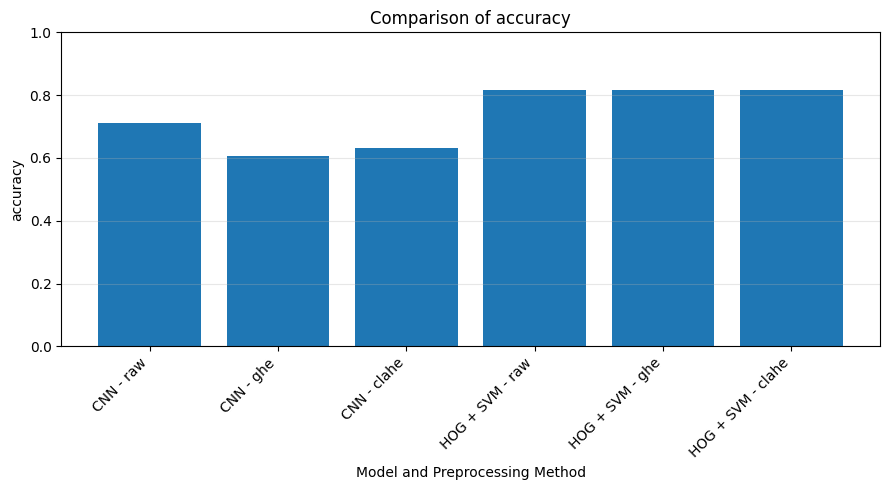

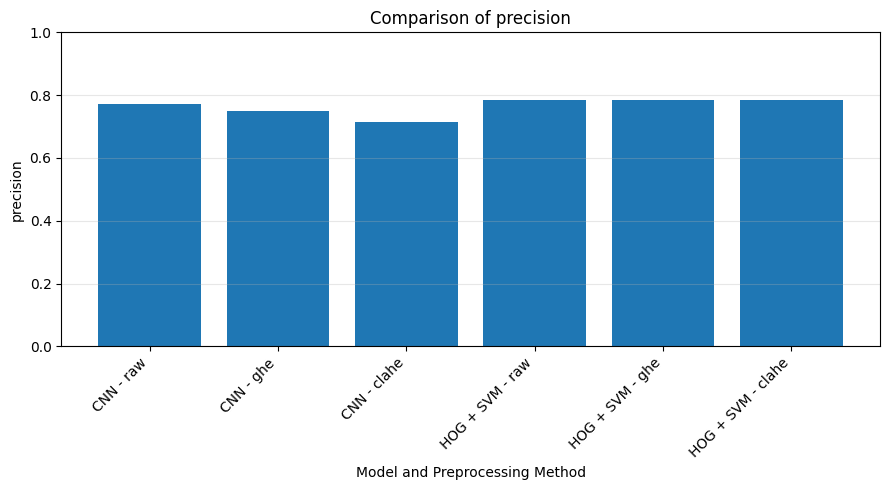

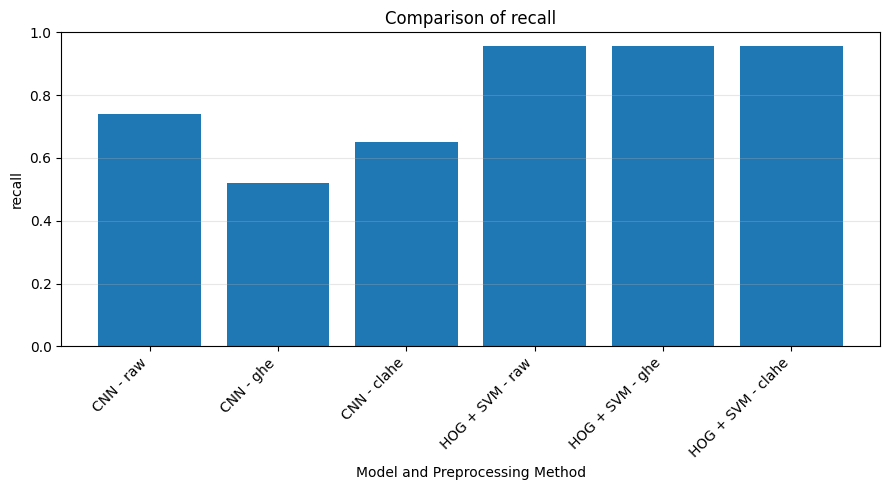

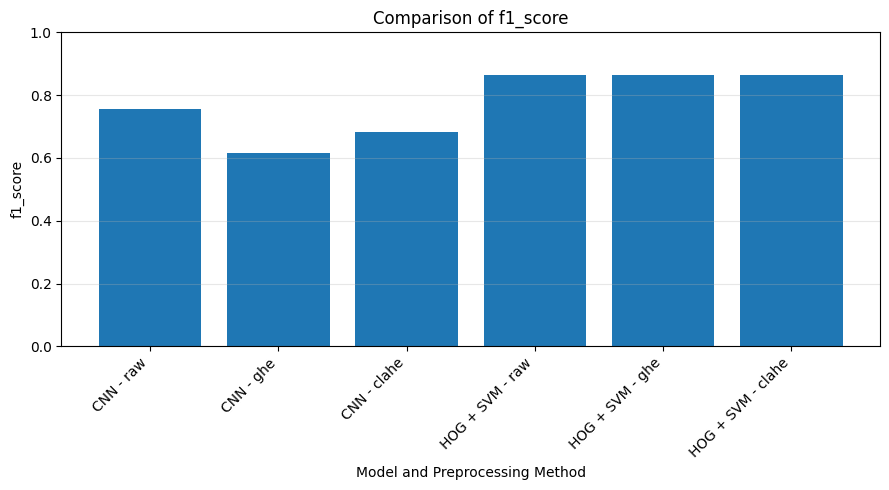

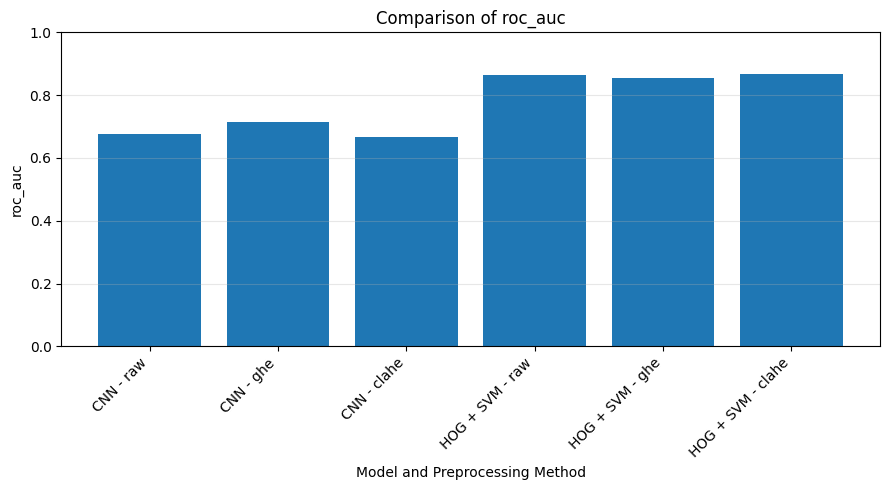

In [5]:
metrics_to_plot = ["accuracy", "precision", "recall", "f1_score", "roc_auc"]

for metric in metrics_to_plot:
    plt.figure(figsize=(9, 5))
    
    labels = (
        combined_results_df["model"].astype(str)
        + " - "
        + combined_results_df["preprocessing"].astype(str)
    )
    
    plt.bar(labels, combined_results_df[metric])
    plt.title(f"Comparison of {metric}")
    plt.xlabel("Model and Preprocessing Method")
    plt.ylabel(metric)
    plt.ylim(0, 1)
    plt.xticks(rotation=45, ha="right")
    plt.grid(axis="y", alpha=0.3)
    plt.tight_layout()
    
    plt.savefig(FIGURES_DIR / f"final_comparison_{metric}.png", dpi=300, bbox_inches="tight")
    plt.show()

In [6]:
ranked_by_f1 = combined_results_df.sort_values(
    by=["f1_score", "roc_auc"],
    ascending=False
)

display(ranked_by_f1)

,model,preprocessing,accuracy,precision,recall,f1_score,roc_auc
5,HOG + SVM,clahe,0.815789,0.785714,0.956522,0.862745,0.866667
3,HOG + SVM,raw,0.815789,0.785714,0.956522,0.862745,0.863768
4,HOG + SVM,ghe,0.815789,0.785714,0.956522,0.862745,0.855072
0,CNN,raw,0.710526,0.772727,0.739130,0.755556,0.675362
2,CNN,clahe,0.631579,0.714286,0.652174,0.681818,0.666667
1,CNN,ghe,0.605263,0.750000,0.521739,0.615385,0.713043


In [7]:
best_overall = ranked_by_f1.iloc[0]

print("Best overall method based on F1-score and ROC-AUC:")
print(best_overall)

Best overall method based on F1-score and ROC-AUC:
model            HOG + SVM
preprocessing        clahe
accuracy          0.815789
precision         0.785714
recall            0.956522
f1_score          0.862745
roc_auc           0.866667
Name: 5, dtype: object


In [8]:
methods = ["raw", "ghe", "clahe"]

processed_data = {}

for method in methods:
    data_path = PROCESSED_DIR / f"{method}_data.npz"
    data = np.load(data_path)
    
    X_all = np.concatenate(
        [data["X_train"], data["X_val"], data["X_test"]],
        axis=0
    )
    
    y_all = np.concatenate(
        [data["y_train"], data["y_val"], data["y_test"]],
        axis=0
    )
    
    processed_data[method] = {
        "X": X_all,
        "y": y_all
    }
    
    print(method.upper())
    print("X shape:", X_all.shape)
    print("y shape:", y_all.shape)
    print("Minimum pixel value:", X_all.min())
    print("Maximum pixel value:", X_all.max())
    print()

RAW
X shape: (253, 128, 128, 1)
y shape: (253,)
Minimum pixel value: 0.0
Maximum pixel value: 1.0

GHE
X shape: (253, 128, 128, 1)
y shape: (253,)
Minimum pixel value: 0.0
Maximum pixel value: 1.0

CLAHE
X shape: (253, 128, 128, 1)
y shape: (253,)
Minimum pixel value: 0.003921569
Maximum pixel value: 1.0



In [9]:
def calculate_entropy(image):
    """
    Calculates Shannon entropy for one normalized grayscale image.
    Input image is expected in range [0,1].
    """
    image_2d = image.squeeze()
    image_uint8 = (image_2d * 255).astype(np.uint8)
    
    counts, _ = np.histogram(
        image_uint8.ravel(),
        bins=256,
        range=(0, 256)
    )
    
    probabilities = counts / counts.sum()
    probabilities = probabilities[probabilities > 0]
    
    entropy = -np.sum(probabilities * np.log2(probabilities))
    
    return entropy

In [10]:
def calculate_sobel_edge_energy(image):
    """
    Calculates Sobel gradient energy for one normalized grayscale image.
    """
    image_2d = image.squeeze().astype("float32")
    
    gradient_x = cv2.Sobel(image_2d, cv2.CV_64F, 1, 0, ksize=3)
    gradient_y = cv2.Sobel(image_2d, cv2.CV_64F, 0, 1, ksize=3)
    
    edge_energy = np.mean(gradient_x**2 + gradient_y**2)
    
    return edge_energy

In [18]:
method_order = ["raw", "ghe", "clahe"]

image_summary_df["preprocessing"] = pd.Categorical(
    image_summary_df["preprocessing"],
    categories=method_order,
    ordered=True
)

image_summary_df = image_summary_df.sort_values("preprocessing")

In [19]:
image_analysis_rows = []

for method in methods:
    X = processed_data[method]["X"]
    y = processed_data[method]["y"]
    
    for image, label in zip(X, y):
        entropy = calculate_entropy(image)
        sobel_energy = calculate_sobel_edge_energy(image)
        
        image_analysis_rows.append({
            "preprocessing": method,
            "label": label,
            "class_name": "tumor" if label == 1 else "no_tumor",
            "entropy": entropy,
            "sobel_edge_energy": sobel_energy,
            "mean_intensity": image.mean(),
            "std_intensity": image.std()
        })

image_analysis_df = pd.DataFrame(image_analysis_rows)

display(image_analysis_df.head())

image_analysis_df.to_csv(RESULTS_DIR / "image_level_analysis.csv", index=False)

,preprocessing,label,class_name,entropy,sobel_edge_energy,mean_intensity,std_intensity
0,raw,1,tumor,6.751464,0.523439,0.247218,0.217601
1,raw,1,tumor,6.844186,0.472825,0.356559,0.304140
2,raw,1,tumor,6.015546,0.293300,0.302406,0.222595
3,raw,0,no_tumor,5.619158,0.282253,0.214345,0.191288
4,raw,0,no_tumor,5.500246,0.517805,0.189554,0.224549


In [20]:
image_summary_df = image_analysis_df.groupby("preprocessing").agg(
    entropy_mean=("entropy", "mean"),
    entropy_std=("entropy", "std"),
    sobel_energy_mean=("sobel_edge_energy", "mean"),
    sobel_energy_std=("sobel_edge_energy", "std"),
    mean_intensity=("mean_intensity", "mean"),
    std_intensity=("std_intensity", "mean")
).reset_index()

display(image_summary_df)

image_summary_df.to_csv(RESULTS_DIR / "image_level_summary_by_method.csv", index=False)

,preprocessing,entropy_mean,entropy_std,sobel_energy_mean,sobel_energy_std,mean_intensity,std_intensity
0,clahe,6.698058,0.864308,0.903524,0.223355,0.341144,0.278028
1,ghe,5.787754,0.824412,0.832153,0.298096,0.457708,0.290440
2,raw,6.029596,0.849230,0.546835,0.259159,0.247987,0.217171


In [21]:
image_class_summary_df = image_analysis_df.groupby(
    ["preprocessing", "class_name"]
).agg(
    entropy_mean=("entropy", "mean"),
    entropy_std=("entropy", "std"),
    sobel_energy_mean=("sobel_edge_energy", "mean"),
    sobel_energy_std=("sobel_edge_energy", "std"),
    mean_intensity=("mean_intensity", "mean"),
    std_intensity=("std_intensity", "mean")
).reset_index()

display(image_class_summary_df)

image_class_summary_df.to_csv(
    RESULTS_DIR / "image_level_summary_by_method_and_class.csv",
    index=False
)

,preprocessing,class_name,entropy_mean,entropy_std,sobel_energy_mean,sobel_energy_std,mean_intensity,std_intensity
0,clahe,no_tumor,6.288328,0.983471,0.853548,0.230838,0.294314,0.273243
1,clahe,tumor,6.957113,0.662429,0.935121,0.213252,0.370753,0.281053
2,ghe,no_tumor,5.326056,0.816660,0.777057,0.311344,0.440925,0.290046
3,ghe,tumor,6.079667,0.686050,0.866989,0.284955,0.468319,0.290688
4,raw,no_tumor,5.539689,0.839110,0.487086,0.237274,0.203782,0.202586
5,raw,tumor,6.339344,0.698095,0.584612,0.265959,0.275936,0.226392


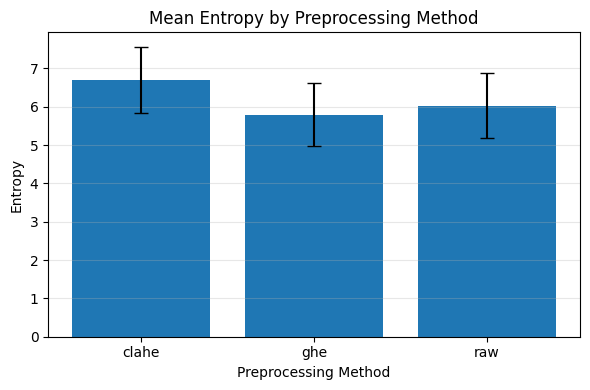

In [22]:
plt.figure(figsize=(6, 4))

plt.bar(
    image_summary_df["preprocessing"],
    image_summary_df["entropy_mean"],
    yerr=image_summary_df["entropy_std"],
    capsize=5
)

plt.title("Mean Entropy by Preprocessing Method")
plt.xlabel("Preprocessing Method")
plt.ylabel("Entropy")
plt.grid(axis="y", alpha=0.3)
plt.tight_layout()

plt.savefig(FIGURES_DIR / "entropy_by_preprocessing.png", dpi=300, bbox_inches="tight")
plt.show()

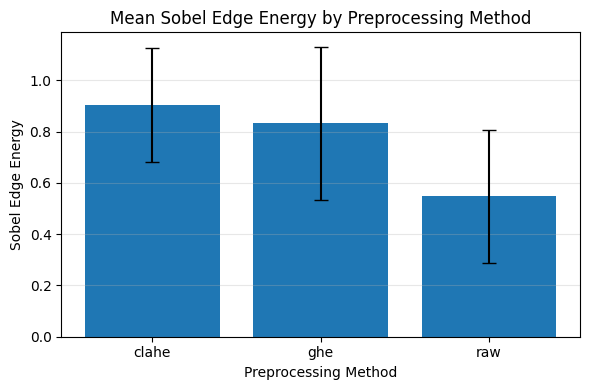

In [23]:
plt.figure(figsize=(6, 4))

plt.bar(
    image_summary_df["preprocessing"],
    image_summary_df["sobel_energy_mean"],
    yerr=image_summary_df["sobel_energy_std"],
    capsize=5
)

plt.title("Mean Sobel Edge Energy by Preprocessing Method")
plt.xlabel("Preprocessing Method")
plt.ylabel("Sobel Edge Energy")
plt.grid(axis="y", alpha=0.3)
plt.tight_layout()

plt.savefig(FIGURES_DIR / "sobel_energy_by_preprocessing.png", dpi=300, bbox_inches="tight")
plt.show()

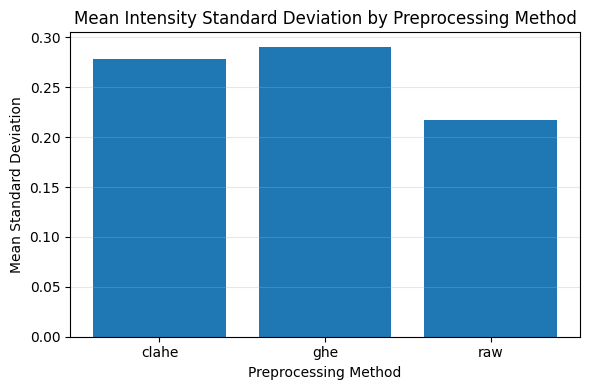

In [24]:
plt.figure(figsize=(6, 4))

plt.bar(
    image_summary_df["preprocessing"],
    image_summary_df["std_intensity"]
)

plt.title("Mean Intensity Standard Deviation by Preprocessing Method")
plt.xlabel("Preprocessing Method")
plt.ylabel("Mean Standard Deviation")
plt.grid(axis="y", alpha=0.3)
plt.tight_layout()

plt.savefig(FIGURES_DIR / "intensity_std_by_preprocessing.png", dpi=300, bbox_inches="tight")
plt.show()

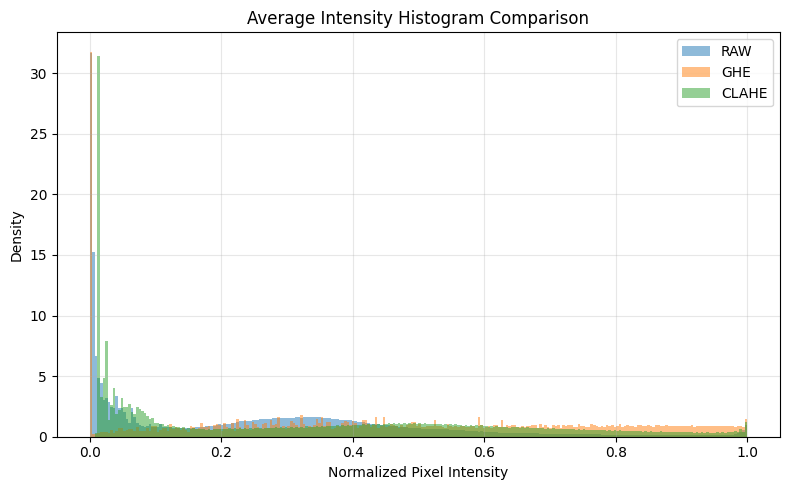

In [25]:
plt.figure(figsize=(8, 5))

for method in methods:
    X = processed_data[method]["X"]
    
    all_pixels = X.ravel()
    
    plt.hist(
        all_pixels,
        bins=256,
        range=(0, 1),
        alpha=0.5,
        density=True,
        label=method.upper()
    )

plt.title("Average Intensity Histogram Comparison")
plt.xlabel("Normalized Pixel Intensity")
plt.ylabel("Density")
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()

plt.savefig(FIGURES_DIR / "average_intensity_histogram_comparison.png", dpi=300, bbox_inches="tight")
plt.show()

In [26]:
final_table = combined_results_df.copy()

numeric_cols = ["accuracy", "precision", "recall", "f1_score", "roc_auc"]
final_table[numeric_cols] = final_table[numeric_cols].round(4)

display(final_table)

final_table.to_csv(RESULTS_DIR / "final_results_table_rounded.csv", index=False)

,model,preprocessing,accuracy,precision,recall,f1_score,roc_auc
0,CNN,raw,0.7105,0.7727,0.7391,0.7556,0.6754
1,CNN,ghe,0.6053,0.7500,0.5217,0.6154,0.7130
2,CNN,clahe,0.6316,0.7143,0.6522,0.6818,0.6667
3,HOG + SVM,raw,0.8158,0.7857,0.9565,0.8627,0.8638
4,HOG + SVM,ghe,0.8158,0.7857,0.9565,0.8627,0.8551
5,HOG + SVM,clahe,0.8158,0.7857,0.9565,0.8627,0.8667


The results should be considered as preliminary, since the dataset contains only 253 images, and the test set contains 38 images. The slight differences in the train test split can influence the final metrics. Future work should test the same preprocessing approaches on larger MRI datasets, and repeated random splits.